Updated Code:
Last ran on (4/26) with updated parameters



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import torch
from PIL import Image

from datasets import Dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

Mounted at /content/drive


In [ ]:
data_path = "/content/drive/MyDrive/DementiaNetProject/data"

test_df = pd.read_csv(f"{data_path}/valid_img.csv", sep="\t")

print(test_df.head())

                    file       label  \
0        AlPacino_3_seg3  nodementia   
1  mauricehinchey_5_seg0    dementia   
2   Chuck norris_3_seg12  nodementia   
3    BrianDePalma_1_seg7  nodementia   
4     KennyRogers_1_seg1  nodementia   

                                                path  
0  /content/drive/MyDrive/DementiaNetProject/data...  
1  /content/drive/MyDrive/DementiaNetProject/data...  
2  /content/drive/MyDrive/DementiaNetProject/data...  
3  /content/drive/MyDrive/DementiaNetProject/data...  
4  /content/drive/MyDrive/DementiaNetProject/data...  


In [ ]:
model_path = "/content/drive/MyDrive/DementiaNetProject/resnet_model"
model_name = "microsoft/resnet-18"

processor = AutoImageProcessor.from_pretrained(model_name)

model = AutoModelForImageClassification.from_pretrained(model_path)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

The image processor of type `ConvNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/122 [00:00<?, ?it/s]

ResNetForImageClassification(
  (resnet): ResNetModel(
    (embedder): ResNetEmbeddings(
      (embedder): ResNetConvLayer(
        (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activation): ReLU()
      )
      (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (encoder): ResNetEncoder(
      (stages): ModuleList(
        (0): ResNetStage(
          (layers): Sequential(
            (0): ResNetBasicLayer(
              (shortcut): Identity()
              (layer): Sequential(
                (0): ResNetConvLayer(
                  (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                  (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                  (activation): ReLU()
           

In [ ]:
label_list = sorted(test_df["label"].unique())
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

In [ ]:
y_true = []
y_pred = []

with torch.no_grad():
    for _, row in test_df.iterrows():
        img = Image.open(row["path"]).convert("RGB")

        inputs = processor(images=img, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = model(**inputs)
        logits = outputs.logits

        pred = torch.argmax(logits, dim=1).item()

        y_pred.append(pred)
        y_true.append(label2id[row["label"]])

In [ ]:
print("Accuracy:", accuracy_score(y_true, y_pred))

Accuracy: 0.5637319316688568


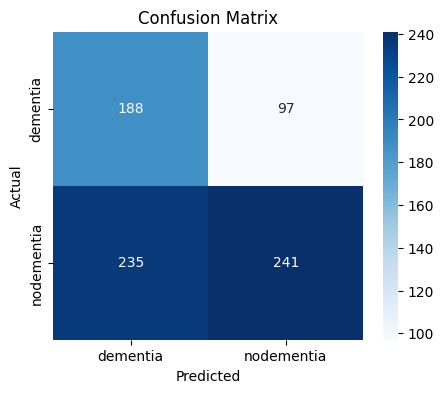

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_list,
            yticklabels=label_list)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_true, y_pred, target_names=label_list))

              precision    recall  f1-score   support

    dementia       0.44      0.66      0.53       285
  nodementia       0.71      0.51      0.59       476

    accuracy                           0.56       761
   macro avg       0.58      0.58      0.56       761
weighted avg       0.61      0.56      0.57       761



In [ ]:
y_true = []
y_pred = []
y_score = []  # store probabilities for ROC

with torch.no_grad():
    for _, row in test_df.iterrows():
        img = Image.open(row["path"]).convert("RGB")

        inputs = processor(images=img, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = model(**inputs)
        logits = outputs.logits

        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

        pred = np.argmax(probs)

        y_pred.append(pred)
        y_true.append(label2id[row["label"]])
        y_score.append(probs)

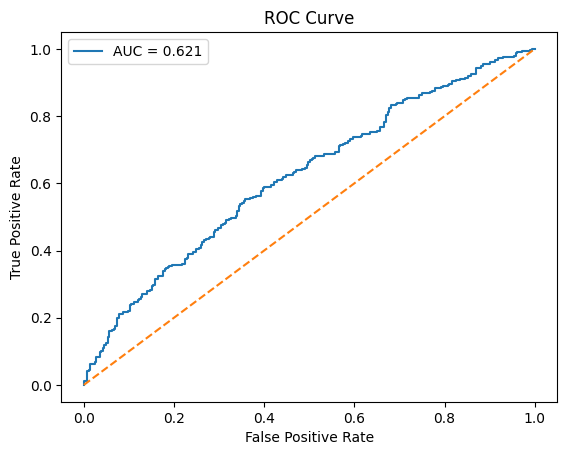

In [ ]:
from sklearn.metrics import roc_curve, auc

y_true = np.array(y_true)
y_score = np.array(y_score)

# probability of class "dementia" (assumed class 1)
fpr, tpr, _ = roc_curve(y_true, y_score[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

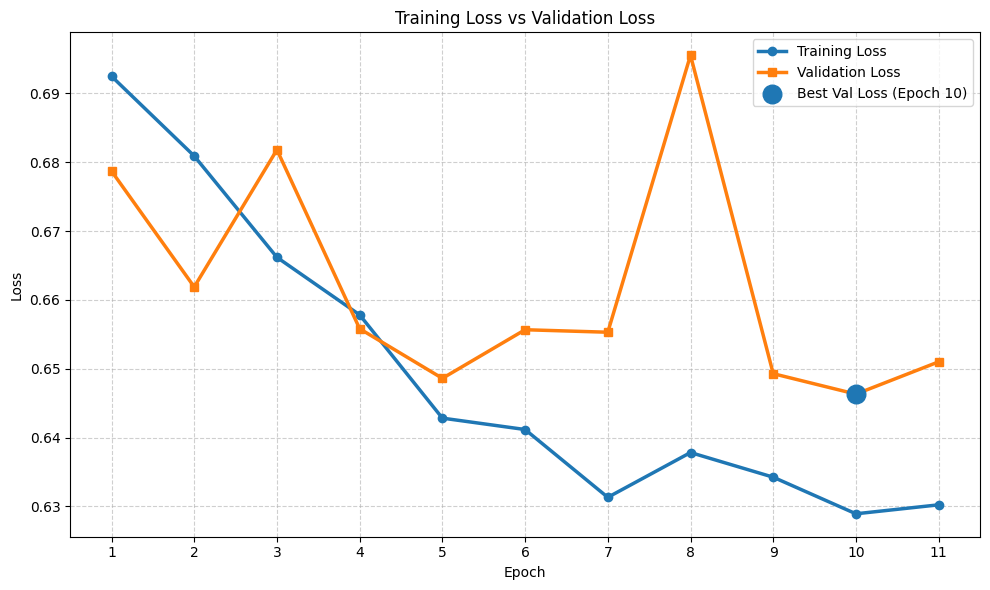

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
epochs = np.arange(1, 12)

train_loss = [
    0.692490,
    0.680903,
    0.666186,
    0.657828,
    0.642828,
    0.641173,
    0.631322,
    0.637829,
    0.634248,
    0.628931,
    0.630234
]

val_loss = [
    0.678714,
    0.661881,
    0.681809,
    0.655815,
    0.648607,
    0.655668,
    0.655305,
    0.695538,
    0.649284,
    0.646317,
    0.651005
]

# Best Validation Loss
best_idx = np.argmin(val_loss)
best_epoch = epochs[best_idx]
best_val = val_loss[best_idx]

# Plot
plt.figure(figsize=(10,6))

plt.plot(
    epochs,
    train_loss,
    marker='o',
    linewidth=2.5,
    label='Training Loss'
)

plt.plot(
    epochs,
    val_loss,
    marker='s',
    linewidth=2.5,
    label='Validation Loss'
)

# Highlight best val loss
plt.scatter(
    best_epoch,
    best_val,
    s=180,
    zorder=5,
    label=f'Best Val Loss (Epoch {best_epoch})'
)

# Labels
plt.title("Training Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

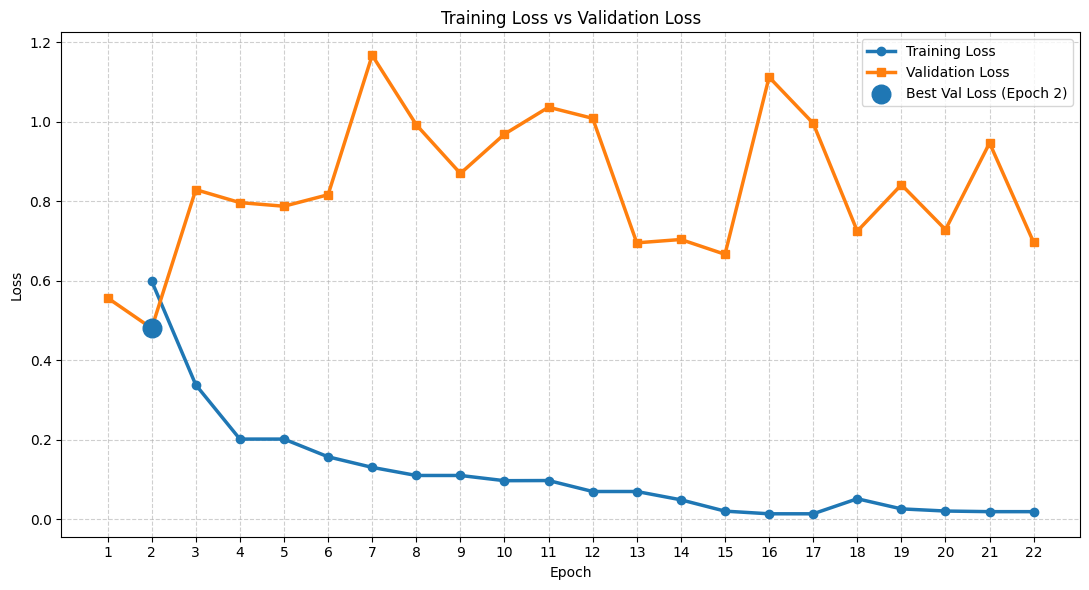

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data
epochs = np.arange(1, 23)

train_loss = [
    np.nan,   # Epoch 1 = No log
    0.598800,
    0.337633,
    0.201188,
    0.201188,
    0.156580,
    0.130007,
    0.109639,
    0.109639,
    0.096520,
    0.096893,
    0.069307,
    0.069307,
    0.048411,
    0.019916,
    0.013220,
    0.013220,
    0.051050,
    0.025592,
    0.020155,
    0.018608,
    0.018608
]

val_loss = [
    0.556450,
    0.480001,
    0.828767,
    0.796167,
    0.787052,
    0.815950,
    1.166890,
    0.992002,
    0.869529,
    0.968502,
    1.036203,
    1.008200,
    0.694956,
    0.703349,
    0.666083,
    1.111882,
    0.995694,
    0.724286,
    0.841146,
    0.728105,
    0.946124,
    0.695849
]

# Best Validation Loss
best_idx = np.argmin(val_loss)
best_epoch = epochs[best_idx]
best_val = val_loss[best_idx]

# Plot
plt.figure(figsize=(11,6))

plt.plot(
    epochs,
    train_loss,
    marker='o',
    linewidth=2.5,
    label='Training Loss'
)

plt.plot(
    epochs,
    val_loss,
    marker='s',
    linewidth=2.5,
    label='Validation Loss'
)

# Highlight best validation point
plt.scatter(
    best_epoch,
    best_val,
    s=180,
    zorder=5,
    label=f'Best Val Loss (Epoch {best_epoch})'
)

# Labels
plt.title("Training Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()